# LLM을 활용한 Instruction Tuning (지시 기반 미세조정)

Instruction 기반 미세조정(instruction fine-tuning)은 흔히 instruction GPT라고 불립니다. 언어 모델이 **특정 지시(instruction)를 따르고 그에 맞는 응답을 생성하도록** 학습시키는 방법입니다. Instruction tuning에서는 데이터셋이 매우 중요한 역할을 합니다. 지시, 문맥(context), 응답으로 구성된 구조화된 예시를 제공하여, 모델이 다양한 작업을 효과적으로 처리하는 법을 학습하게 하기 때문입니다. Instruction GPT는 종종 사람의 피드백(human feedback)을 활용해 성능을 개선하지만, 이 실습에서는 그 부분은 다루지 않습니다.

문맥(context)과 지시(instruction)는 하나의 입력 시퀀스로 연결(concatenate)되어, 모델이 이를 이해하고 올바른 응답을 생성하는 데 사용됩니다.

#### 문맥(Context)과 지시(Instruction)

- **Instruction(지시):** 모델이 무엇을 해야 하는지 지정하는 명령
- **Context(문맥):** 지시를 수행하는 데 필요한 추가 정보나 배경
- **Combined input(결합 입력):** 지시와 문맥이 하나의 입력 시퀀스로 결합됨

아래에서 다양한 템플릿 예시를 살펴보겠습니다.

---
#### Response 템플릿
템플릿: `### Question: {question}\n ### Answer: {answer}`

예시:
```
### Question: What is the capital of France?
### Answer: Paris
```

---
#### Conversation 템플릿

템플릿: `### User: {user_input}\n ### Bot: {bot_response}`

예시:
```
### User: How are you today?
### Bot: I'm doing great, thank you! How can I assist you today?
```

---
#### Instruction and output 템플릿

템플릿: `### Instruction: {instruction}\n ### Output: {output}`

예시:
```
### Instruction: Translate the following sentence to Spanish: "Hello, how are you?"
### Output: "Hola, ¿cómo estás?"
```

---
#### Completion 템플릿

템플릿: `{prompt} ### Completion: {completion}`

예시:
```
Once upon a time in a faraway land, ### Completion: there lived a wise old owl who knew all the secrets of the forest.
```

#### Summarization 템플릿

템플릿: `### Text: {text}\n ### Summary: {summary}`

예시:
```
### Text: The quick brown fox jumps over the lazy dog.
### Summary: A fox jumps over a dog.
```

---
#### Dialogue 템플릿

템플릿: `### Speaker 1: {utterance_1}\n ### Speaker 2: {utterance_2}\n ### Speaker 1: {utterance_3}`

예시:
```
### Speaker 1: Hi, what are you doing today?
### Speaker 2: I'm going to the park.
### Speaker 1: That sounds fun!
```

---
#### Code generation 템플릿

템플릿: `### Task: {task_description}\n ### Code: {code_output}`

예시:
```
### Task: Write a function to add two numbers in Python.
### Code: def add(a, b):\n    return a + b
```

---
#### Data analysis 템플릿

템플릿: `### Analysis Task: {task_description}\n ### Analysis: {analysis_output}`

예시:
```
### Analysis Task: Provide insights from the sales data of Q1 2022.
### Analysis: The sales increased by 15% compared to Q4 2021, with the highest growth in the electronics category.
```

---
#### Recipe 템플릿

템플릿: `### Recipe Name: {recipe_name}\n ### Ingredients: {ingredients}\n ### Instructions: {instructions}`

예시:
```
### Recipe Name: Chocolate Chip Cookies
### Ingredients: Flour, Sugar, Chocolate Chips, Butter, Eggs, Vanilla Extract
### Instructions: Mix the dry ingredients, add the wet ingredients, fold in the chocolate chips, and bake at 350°F for 10-12 minutes.
```

---
#### Explanation 템플릿

템플릿: `### Concept: {concept}\n ### Explanation: {explanation}`

예시:
```
### Concept: Photosynthesis
### Explanation: Photosynthesis is the process by which green plants use sunlight to synthesize nutrients from carbon dioxide and water.
```

---

## 학습 목표

이 실습을 마치면 다음을 할 수 있습니다:

- instruction-response, question-answering, summarization, code generation, dialogue, data analysis, explanation 등 다양한 템플릿의 종류와, 이들을 LLM 미세조정에 어떻게 활용하는지 이해하기
- 다양한 작업을 위해 여러 템플릿을 만들고 적용하기
- 만든 템플릿에 맞춰 데이터셋을 포맷하여 효과적인 모델 학습을 준비하기
- Hugging Face 라이브러리와 도구를 사용해 instruction 미세조정 수행하기
- LoRA(Low-Rank Adaptation) 기법을 적용해 LLM을 효율적으로 미세조정하기
- SFTTrainer를 설정하고 사용해 instruction-following 모델을 지도 미세조정(supervised fine-tuning)하기


## 목차

1. [환경 설정](#setup)
    1. 필요한 라이브러리 설치
    2. 필요한 라이브러리 임포트
    3. 디바이스 정의
2. 데이터셋 설명
3. 모델과 토크나이저
4. 데이터 전처리
5. 베이스 모델 테스트
    1. BLEU 점수
6. LoRA를 활용한 instruction 미세조정
7. 연습 문제

<a id="setup"></a>
# 환경 설정

### 필요한 라이브러리 설치

이 실습에 필요한 라이브러리를 아래 셀을 실행하여 설치합니다.

In [2]:
%%time
%pip install -qq -U trl transformers peft datasets accelerate evaluate sacrebleu
%pip uninstall -y -qq torchao

import trl, transformers, peft, datasets
print("trl:", trl.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("datasets:", datasets.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 4.3 MB/s eta 0:00:00
trl: 1.9.2
transformers: 5.14.1
peft: 0.20.0
datasets: 5.0.1
CPU times: user 14.9 s, sys: 2.18 s, total: 17 s
Wall time: 59.9 s


### 필요한 라이브러리 임포트

아래 코드는 필요한 라이브러리들을 임포트합니다.

In [3]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from datasets import load_dataset
import torch
from torch.utils.data import Dataset
from tqdm import tqdm
import evaluate
from trl import SFTConfig, SFTTrainer

from peft import get_peft_model, LoraConfig, TaskType

import pickle
import json
import matplotlib.pyplot as plt

from urllib.request import urlopen
import io

### 디바이스 정의

아래 코드는 GPU 사용이 가능한 경우 디바이스를 `'cuda'`로, 그렇지 않으면 `'cpu'`로 설정합니다. (Colab에서 GPU 런타임을 선택했다면 `cuda`로 잡힙니다.)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# 데이터셋 설명

아래 코드로 프로그래밍 코드 데이터셋인 **CodeAlpaca 20k** 데이터셋을 다운로드합니다. 이 데이터는 [여기](https://github.com/sahil280114/codealpaca?tab=readme-ov-file#data-release)에서 확인할 수 있습니다. CodeAlpaca 데이터셋은 다음 요소로 구성됩니다:

- `instruction`: **str**, 모델이 수행해야 할 작업을 설명합니다. 2만 개의 지시는 각각 고유합니다.
- `input`: **str**, 작업에 대한 선택적 문맥 또는 입력입니다. 예를 들어 지시가 "다음 SQL 쿼리를 distinct 요소를 선택하도록 수정하라"인 경우, input은 해당 SQL 쿼리가 됩니다. 전체 예시의 약 40%가 input을 가지고 있습니다.
- `output`: **str**, text-davinci-003이 생성한 지시에 대한 답변입니다.

아래 코드 블록은 CodeAlpaca-20k 데이터셋을 `json` 파일로 다운로드합니다:

In [5]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/WzOT_CwDALWedTtXjwH7bA/CodeAlpaca-20k.json

--2026-08-04 07:33:46--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/WzOT_CwDALWedTtXjwH7bA/CodeAlpaca-20k.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6957007 (6.6M) [application/json]
Saving to: ‘CodeAlpaca-20k.json’

CodeAlpaca-20k.json 100%[===================>]   6.63M  --.-KB/s    in 0.1s    

2026-08-04 07:33:46 (50.9 MB/s) - ‘CodeAlpaca-20k.json’ saved [6957007/6957007]



다음으로 데이터셋을 불러옵니다:

In [6]:
dataset = load_dataset(
    "json",
    data_files="CodeAlpaca-20k.json",
    split="train"
)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['output', 'instruction', 'input'],
    num_rows: 20022
})

데이터셋의 예시를 하나 살펴보겠습니다:

In [7]:
dataset[1000]

{'output': 's = "Hello world" \ns = s[::-1] \nprint(s)',
 'instruction': 'Reverse the string given in the input',
 'input': 'Hello world'}

단순화를 위해, `input`이 없는 예시들만 사용하겠습니다:

In [8]:
dataset = dataset.filter(lambda example: example["input"] == '')

Filter:   0%|          | 0/20022 [00:00<?, ? examples/s]

원본 CodeAlpaca 데이터셋은 섞여(shuffle) 있지 않을 수 있습니다. 아래는 랜덤 시드를 사용해 `datasets.arrow_dataset.Dataset()` 객체를 섞는 방법입니다:

In [9]:
dataset = dataset.shuffle(seed=42)

In [10]:
dataset

Dataset({
    features: ['output', 'instruction', 'input'],
    num_rows: 9764
})

CodeAlpaca 20k 데이터셋에는 학습 세트와 테스트 세트가 있습니다. 원본 학습 데이터를 80%는 학습 세트, 20%는 테스트 세트로 나눌 수 있습니다.

In [11]:
dataset_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split['train']
test_dataset = dataset_split['test']
dataset_split

DatasetDict({
    train: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 7811
    })
    test: Dataset({
        features: ['output', 'instruction', 'input'],
        num_rows: 1953
    })
})

리소스 제약을 고려해, 평가용으로 작은 데이터 집합을 선택합니다. (이 데이터는 학습이 아닌 평가 부분에서만 사용됩니다.)

In [12]:
tiny_test_dataset = test_dataset.select(range(10))
tiny_train_dataset = train_dataset.select(range(10))

# 모델과 토크나이저

이 실습에서는 Facebook의 [`opt-350m`](https://huggingface.co/facebook/opt-350m) 모델을 미세조정합니다. 이 오픈소스 모델에 대한 설명은 [여기](https://arxiv.org/abs/2205.01068)에 발표되어 있으며, 모델은 [metaseq의 Github 저장소](https://github.com/facebookresearch/metaseq)에서 처음 공개되었습니다.

아래 코드는 Hugging Face에서 베이스 모델을 불러옵니다:

In [13]:
model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m").to(device)

config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  663MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  662MB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

이 모델은 자체 토크나이저를 함께 제공하며, 여기서 불러옵니다:

In [14]:
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m", padding_side='left')

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

문장의 끝(EOS, end of sentence) 토큰을 확인해 봅니다. 이는 특수 토크나이저 토큰으로, 이 토큰이 나타나면 모델은 더 이상 토큰을 생성하지 않고 멈춥니다:

In [15]:
tokenizer.eos_token

'</s>'

# 데이터 전처리

미세조정을 위해 데이터를 전처리합니다. 여기서는 두 가지를 준비합니다.

1. **평가용 프롬프트 생성 함수** — 베이스/미세조정 모델에 넣을 입력(응답 제외)과, 비교 대상인 기대 응답(`expected_outputs`)을 만듭니다.
2. **학습용 prompt-completion 데이터셋** — 최신 `trl`의 `SFTTrainer`는 `prompt`/`completion` 두 컬럼을 가진 데이터셋을 받으면, 프롬프트 토큰은 손실에서 자동으로 무시(마스킹)하고 **completion(응답) 토큰에 대해서만 손실을 계산**합니다.

먼저 프롬프트 형식을 정의합니다. 아래 형식을 사용합니다:

```
### Instruction:
Translate the following sentence to Spanish: "Hello, how are you?"

### Response:
"Hola, ¿cómo estás?"
```

`formatting_prompts_func`는 instruction과 output을 합쳐 전체 텍스트(응답 포함)를 만들고, `formatting_prompts_func_no_response`는 동일하지만 응답을 포함하지 않습니다. (이 두 함수는 주로 **평가**에 사용됩니다.)

***참고:*** `### Response:`를 `### Output:`으로 바꿔도 비슷한 결과를 얻을 수 있습니다.

In [16]:
def formatting_prompts_func(mydataset):
  output_texts = []
  for i in range(len(mydataset['instruction'])):
    text = (
        f"### Instruction:\n{mydataset['instruction'][i]}"
        f"\n\n### Response:\n{mydataset['output'][i]}"
    )
    output_texts.append(text)
  return output_texts

def formatting_prompts_func_no_response(mydataset):
  output_texts = []
  for i in range(len(mydataset['instruction'])):
    text = (
        f"### Instruction: \n{mydataset['instruction'][i]}"
        f"\n\n### Response:\n"
    )
    output_texts.append(text)
  return output_texts

아래 코드 블록은 평가에 필요한 세 가지를 만듭니다: `instructions`(응답을 제외한 프롬프트), `instructions_with_responses`(응답을 포함한 전체 텍스트), 그리고 `expected_outputs`(둘 사이의 차이, 즉 기대 응답).

`expected_outputs`를 얻기 위해 `instructions`와 `instructions_with_responses`를 각각 토큰화하고, `instructions`의 토큰 길이만큼 앞부분을 잘라낸 나머지를 디코딩합니다:

In [17]:
expected_outputs = []
instructions_with_responses = formatting_prompts_func(test_dataset)
instructions = formatting_prompts_func_no_response(test_dataset)
for i in tqdm(range(len(instructions_with_responses))):
    tokenized_instruction_with_response = tokenizer(instructions_with_responses[i], return_tensors="pt", max_length=1024, truncation=True, padding=False)
    tokenized_instruction = tokenizer(instructions[i], return_tensors="pt")

    response_ids = tokenized_instruction_with_response['input_ids'][0][len(tokenized_instruction['input_ids'][0]):]
    expected_output = tokenizer.decode(response_ids, skip_special_tokens=True)
    expected_outputs.append(expected_output)

100%|██████████| 1953/1953 [00:01<00:00, 1542.70it/s]


`instructions`, `instructions_with_responses`, `expected_outputs`가 각각 무엇을 담고 있는지 예시로 확인해 봅니다:

In [18]:
print('############## instructions ##############\n' + instructions[0])
print('############## instructions_with_responses ##############\n' + instructions_with_responses[0])
print('\n############## expected_outputs ##############' + expected_outputs[0])

############## instructions ##############
### Instruction: 
Name the most important benefit of using a database system.

### Response:

############## instructions_with_responses ##############
### Instruction:
Name the most important benefit of using a database system.

### Response:
The most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.

############## expected_outputs ############## most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.


`instructions` 리스트를 그대로 두기보다, `torch`의 `Dataset` 객체로 변환하는 것이 유용합니다. 아래 코드는 리스트로부터 `torch` `Dataset`을 만드는 `ListDataset` 클래스를 정의하고, 이를 사용해 `instructions`로부터 `Dataset` 객체를 생성합니다:

In [19]:
class ListDataset(Dataset):
  def __init__(self, original_list):
    self.original_list = original_list

  def __len__(self):
    return len(self.original_list)

  def __getitem__(self, i):
    return self.original_list[i]

instructions_torch = ListDataset(instructions)

In [20]:
instructions_torch[0]

'### Instruction: \nName the most important benefit of using a database system.\n\n### Response:\n'

# 베이스 모델 테스트

미세조정 전, 베이스 모델(미세조정하지 않은 모델)이 어떻게 동작하는지 살펴봅니다.

아래 코드는 `transformers`의 `pipeline` 클래스를 사용해 텍스트 생성 파이프라인을 정의합니다. 이 파이프라인은 주어진 모델과 토크나이저로 텍스트를 생성하는 데 유용합니다:

In [23]:
gen_pipeline = pipeline("text-generation",
                          model=model,
                          tokenizer=tokenizer,
                          device=device,
                          batch_size=2,
                          max_length=50,
                          truncation=True,
                          padding=False,
                          return_full_text=False)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


***참고:*** 생성 파이프라인은 토큰 또는 텍스트를 생성할 수 있습니다. `return_tensors=True`이면 토큰 ID를 반환하고, 그렇지 않으면 단어(텍스트)를 반환합니다. 또한 파이프라인은 기본적으로 instruction과 response를 모두 생성합니다. 하지만 모델 성능을 평가할 때는 생성된 instruction을 제외하고 response에만 집중해야 합니다. 이를 위해 `return_full_text=False`로 설정합니다.

아래 코드는 미리 정의한 생성 파이프라인을 사용해 모델로 출력을 생성합니다.

In [26]:
tokenizer.padding_side = 'left'

with torch.no_grad():
  pipeline_iterator = gen_pipeline(instructions_torch[:3],
                                   max_length=50,
                                   num_beams=5,
                                   early_stopping=True,)
generated_outputs_base = []
for text in pipeline_iterator:
    generated_outputs_base.append(text[0]["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'num_beams', 'max_length', 'early_stopping'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


아래 코드는 빠른 CUDA GPU에서 전체 데이터셋에 대해 미리 생성해 둔 응답을 불러옵니다:

In [27]:
urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VvQRrSqS1P0_GobqtL-SKA/instruction-tuning-generated-outputs-base.pkl')
generated_outputs_base = pickle.load(io.BytesIO(urlopened.read()))

베이스 모델이 생성한 샘플 응답과, 데이터셋의 기대 응답을 비교해 봅니다:

In [28]:
for i in range(3):
    print('@@@@@@@@@@@@@@@@@@@@')
    print('@@@@@ Instruction '+ str(i+1) +': ')
    print(instructions[i])
    print('\n\n')
    print('@@@@@ Expected response '+ str(i+1) +': ')
    print(expected_outputs[i])
    print('\n\n')
    print('@@@@@ Generated response '+ str(i+1) +': ')
    print(generated_outputs_base[i])
    print('\n\n')
    print('@@@@@@@@@@@@@@@@@@@@')

@@@@@@@@@@@@@@@@@@@@
@@@@@ Instruction 1: 
### Instruction: 
Name the most important benefit of using a database system.

### Response:




@@@@@ Expected response 1: 
 most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.



@@@@@ Generated response 1: 
Thank you for your question.

### Response:
Thank you for your question.

### Response:
Thank you for your question.

### Response:
Thank you for your question.

### Response:
Thank you for your question.

### Response:
Thank you for your question.



@@@@@@@@@@@@@@@@@@@@
@@@@@@@@@@@@@@@@@@@@
@@@@@ Instruction 2: 
### Instruction: 
Come up with a Java program that checks if one string is a substring of another.

### Response:




@@@@@ Expected response 2: 
 static boolean isSubstring(String s, String x) {
    int i = 0, j = 0;
    while (

베이스 모델이 생성한 응답이 만족스럽지 않다는 것을 볼 수 있습니다. 또한 응답이 최대 토큰 수에 도달할 때까지 답변을 계속 늘어놓고 반복하는 경향이 있습니다. 뒤에서 보겠지만, instruction tuning은 이 두 문제를 모두 해결할 수 있습니다. 첫째, instruction 미세조정된 모델은 더 의미 있는 응답을 제공합니다. 둘째, 출력에 `eos` 토큰 `</s>`를 붙였기 때문에, instruction 미세조정을 통해 모델이 응답을 무한정 생성하지 않도록 가르칠 수 있습니다.

## BLEU 점수

테스트 환경에서 생성된 응답과 기대 응답을 비교하는 지표를 설정합니다. 이 실습에서는 원래 번역 모델의 번역 품질을 확인하기 위해 고안된 지표인 [BLEU 점수](https://en.wikipedia.org/wiki/BLEU)를 사용합니다. 생성된 각 세그먼트를 기대 출력 집합과 비교해 BLEU 점수를 계산하고, 개별 세그먼트의 점수를 평균 냅니다. 구현에 따라 BLEU 점수는 0~1 또는 0 ~ 100(여기서 사용하는 구현) 범위를 가지며, 점수가 높을수록 모델 생성 출력과 기대 출력이 더 잘 일치함을 의미합니다.

***참고:***
1. BLEU 점수는 원래 번역 품질 평가를 위해 구현되었습니다. instruction 미세조정에 반드시 최적의 지표는 아닐 수 있지만, 모델 출력과 기대 출력 간의 정렬 정도를 파악하는 데 유용한 지표입니다.
2. BLEU 점수는 파라미터화된 지표이기 때문에 연구 간 비교가 매우 어렵습니다. 이를 위해 지표의 파라미터화에 영향을 받지 않는 BLEU 변형인 [SacreBLEU](https://aclanthology.org/W18-6319/)를 사용합니다.

In [29]:
sacrebleu = evaluate.load("sacrebleu")
results_base = sacrebleu.compute(predictions=generated_outputs_base,
                                 references=expected_outputs)

print(list(results_base.keys()))
print(round(results_base["score"], 1))

['score', 'counts', 'totals', 'precisions', 'bp', 'sys_len', 'ref_len']
0.0


낮은 SacreBLEU 점수는 베이스 모델이 생성한 응답과 테스트 데이터셋 예시의 기대 응답 간에 정렬이 거의 없음을 나타냅니다.

---

## LoRA를 활용한 instruction 미세조정

시간을 절약하기 위해, 파라미터 효율적 미세조정(PEFT) 기법인 **LoRA(Low-Rank Adaptation)**를 사용해 instruction 미세조정을 수행합니다. 먼저 `peft` 라이브러리의 `LoraConfig` 객체를 정의해 LoRA rank, target modules 등 LoRA 파라미터를 설정하고, 모델을 LoRA 미세조정에 적합한 PEFT 모델로 변환합니다. 그런 다음 `get_peft_model()`을 사용해 모델에 LoRA 설정을 적용하면 `model`이 LoRA `model`로 변환됩니다.

In [30]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_config)

---

## LoRA를 활용한 instruction 미세조정

시간을 절약하기 위해, 파라미터 효율적 미세조정(PEFT) 기법인 **LoRA(Low-Rank Adaptation)**를 사용해 instruction 미세조정을 수행합니다. `peft`의 `LoraConfig`로 LoRA rank·target modules 등을 설정하고, `get_peft_model()`로 모델을 LoRA 모델로 변환합니다.

In [31]:
def to_prompt_completion(example):
    prompt = (
        f"### Instruction:\n{example['instruction']}"
        f"\n\n### Response:\n"
    )
    completion = example['output']
    return {"prompt": prompt, "completion": completion}

train_dataset_pc = train_dataset.map(to_prompt_completion, remove_columns=train_dataset.column_names)
test_dataset_pc = test_dataset.map(to_prompt_completion, remove_columns=test_dataset.column_names)

print(train_dataset_pc[0])

Map:   0%|          | 0/7811 [00:00<?, ? examples/s]

Map:   0%|          | 0/1953 [00:00<?, ? examples/s]

{'prompt': '### Instruction:\nWrite a query in MongoDB to find all documents which have a count greater than 10.\n\n### Response:\n', 'completion': 'db.collection.find( { count: { $gt: 10 } } )'}


위와 같이 `prompt`/`completion` 형식으로 데이터를 준비하면, `SFTConfig(completion_only_loss=True)`(최신 `trl`의 **기본값**)에 의해 프롬프트에 해당하는 토큰은 `-100`으로 마스킹되어 손실 계산에서 제외되고, 응답(completion) 토큰에 대해서만 손실이 계산됩니다. 응답 끝의 EOS 토큰도 `trl`이 자동으로 추가하므로, 모델은 응답을 적절한 지점에서 멈추도록 학습됩니다.

이제 `SFTConfig`와 `SFTTrainer`를 설정합니다.




In [32]:
training_args = SFTConfig(
    output_dir="/tmp",
    num_train_epochs=10,
    save_strategy="epoch",
    fp16=torch.cuda.is_available(),
    use_cpu=not torch.cuda.is_available(),
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    max_length=1024,
    completion_only_loss=True,
    do_eval=True,
    eval_strategy="epoch",
    report_to="none",
)

trainer = SFTTrainer(
    model,
    train_dataset=train_dataset_pc,
    eval_dataset=test_dataset_pc,
    args=training_args,
    processing_class=tokenizer,
)

Adding EOS to train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/7811 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/1953 [00:00<?, ? examples/s]

아래 셀은 trainer를 실행합니다.

In [ ]:
trainer.train()

trainer를 학습시키면, `trainer` 객체는 각 학습 스텝의 상태 이력(state history)을 갖게 됩니다. 아래 주석 처리된 줄로 이 상태 이력에 접근할 수 있습니다:

In [ ]:
log_history_lora = trainer.state.log_history

위에서 상태 이력을 직접 추출하는 대신, 앞서와 동일한 사양으로 GPU에서 instruction 미세조정한 모델의 상태 이력을 불러옵니다.

In [34]:
urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/49I70jQD0-RNRg2v-eOoxg/instruction-tuning-log-history-lora.json')
log_history_lora = json.load(io.BytesIO(urlopened.read()))

각 학습 스텝에 대한 학습 손실(training loss)을 그래프로 그려볼 수 있습니다.

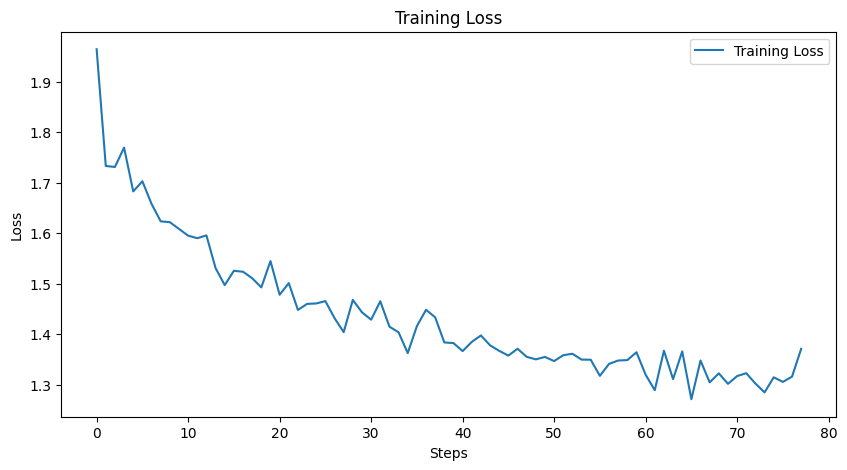

In [35]:
train_loss = [log["loss"] for log in log_history_lora if "loss" in log]

# 학습 손실 그래프
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

모델이 LoRA 모델로 바뀌었으므로, 텍스트 생성 파이프라인을 다시 정의합니다.

In [36]:
gen_pipeline = pipeline("text-generation",
                        model=model,
                        tokenizer=tokenizer,
                        device=device,
                        batch_size=2,
                        max_length=50,
                        truncation=True,
                        padding=False,
                        return_full_text=False)

아래 코드는 instruction 미세조정된 모델로 파이프라인을 사용해 토큰을 생성합니다.

In [37]:
with torch.no_grad():
    pipeline_iterator = gen_pipeline(instructions_torch[:3],
                                max_length=50,
                                num_beams=5,
                                early_stopping=True,)
generated_outputs_lora = []
for text in pipeline_iterator:
    generated_outputs_lora.append(text[0]["generated_text"])

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in OPTDecoderLayer. Setting `past_key_values=None`.


In [38]:
generated_outputs_lora[0]

'\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n'

미세조정된 LoRA 모델로 전체 데이터셋에 대해 GPU에서 생성한 텍스트를 불러올 수 있습니다.

In [39]:
urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/o7uYxe15xvX4CN-6Lr10iA/instruction-tuning-generated-outputs-lora.pkl')
generated_outputs_lora = pickle.load(io.BytesIO(urlopened.read()))

instruction 미세조정된 모델의 응답 일부와 기대 응답을 살펴봅니다.

In [40]:
for i in range(3):
    print('@@@@@@@@@@@@@@@@@@@@')
    print('@@@@@ Instruction '+ str(i+1) +': ')
    print(instructions[i])
    print('\n\n')
    print('@@@@@ Expected response '+ str(i+1) +': ')
    print(expected_outputs[i])
    print('\n\n')
    print('@@@@@ Generated response '+ str(i+1) +': ')
    print(generated_outputs_lora[i])
    print('\n\n')
    print('@@@@@@@@@@@@@@@@@@@@')

@@@@@@@@@@@@@@@@@@@@
@@@@@ Instruction 1: 
### Instruction: 
Name the most important benefit of using a database system.

### Response:




@@@@@ Expected response 1: 
 most important benefit of using a database system is the ability to store and retrieve data quickly and easily. Database systems also provide support for data security, data integrity, and concurrently accessing and modifying data from multiple systems.



@@@@@ Generated response 1: 
The type of data structure to use to store key-value pairs in a Python program would be a key-value pair.



@@@@@@@@@@@@@@@@@@@@
@@@@@@@@@@@@@@@@@@@@
@@@@@ Instruction 2: 
### Instruction: 
Come up with a Java program that checks if one string is a substring of another.

### Response:




@@@@@ Expected response 2: 
 static boolean isSubstring(String s, String x) {
    int i = 0, j = 0;
    while (i < s.length() && j < x.length()) {
        if (s.charAt(i) == x.charAt(j)) {
            i++;
            j++;
        } else {
            i 

베이스 모델과 비교하면 응답이 훨씬 개선된 것을 볼 수 있습니다. 또한 응답이 최대 토큰 수까지 늘어나지 않습니다.

instruction 미세조정된 모델의 응답이 기대 출력과 더 잘 정렬되는지 확인하기 위해 SacreBLEU 점수를 계산해 봅니다:

In [41]:
sacrebleu = evaluate.load("sacrebleu")
results_lora = sacrebleu.compute(predictions=generated_outputs_lora,
                                 references=expected_outputs)
print(list(results_lora.keys()))
print(round(results_lora["score"], 1))

['score', 'counts', 'totals', 'precisions', 'bp', 'sys_len', 'ref_len']
1.2


미세조정된 모델이 베이스 모델보다 훨씬 높은 SacreBLEU 점수를 달성한 것을 볼 수 있습니다.

정리하면, instruction 미세조정된 모델은 데이터셋의 기대 응답과 훨씬 잘 정렬되는 응답을 생성합니다.

